# UNSW-NB15 Gaussian Copula Privacy Evaluation

This notebook loads the UNSW-NB15 dataset, trains an SDV Gaussian Copula synthesizer through the framework wrapper, generates a synthetic dataset with the same number of rows, and evaluates privacy metrics on the result.

In [8]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sdv.metadata import SingleTableMetadata

from privacy_utility_framework.dataset import TableTransformer
from privacy_utility_framework.metrics.privacy import PrivacyMetricManager
from privacy_utility_framework.metrics.privacy.distance import (
    AdversarialAccuracyCalculator_NN,
    NNDRCalculator,
)
from privacy_utility_framework.synthesizers import GaussianCopulaModel

In [9]:
project_root = Path.cwd().parent
DATA_PATH = project_root / "datasets" / "original" / "cybersecurity" / "UNSW_NB15_training-set.csv"
OUTPUT_DIR = project_root / "datasets" / "synthetic" / "unswnb15_datasets"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR = project_root / "synthetic_models" / "unswnb15_models"


def relpath(path: Path) -> Path:
    try:
        return path.resolve().relative_to(project_root.resolve())
    except ValueError:
        return path


LOAD = True

if not MODEL_DIR.exists():
    MODEL_DIR.mkdir(parents=True, exist_ok=True)

# Set MAX_ROWS to an integer for a quicker experiment. Leave as None to use the full dataset.
MAX_ROWS = 5000

# For the nearest-neighbor adversarial accuracy metric, cap the internal comparison sample
# size to keep runtime reasonable on large datasets.
NN_SAMPLES = 1000
MAX_TRIES = 1e3  # Max Singling out tries

In [10]:
original_data = pd.read_csv(DATA_PATH, encoding="utf-8-sig")

if MAX_ROWS is not None:
    original_data = original_data.head(MAX_ROWS).copy()

print(
    f"Loaded {len(original_data):,} rows and {original_data.shape[1]} columns from {DATA_PATH.name}"
)
original_data.head()

Loaded 5,000 rows and 45 columns from UNSW_NB15_training-set.csv


,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,...,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,1,0.121478,tcp,-,FIN,6,4,258,172,74.087490,...,1,1,0,0,0,1,1,0,Normal,0
1,2,0.649902,tcp,-,FIN,14,38,734,42014,78.473372,...,1,2,0,0,0,1,6,0,Normal,0
2,3,1.623129,tcp,-,FIN,8,16,364,13186,14.170161,...,1,3,0,0,0,2,6,0,Normal,0
3,4,1.681642,tcp,ftp,FIN,12,12,628,770,13.677108,...,1,3,1,1,0,2,1,0,Normal,0
4,5,0.449454,tcp,-,FIN,10,6,534,268,33.373826,...,1,40,0,0,0,2,39,0,Normal,0


In [11]:
metadata = SingleTableMetadata()
metadata.detect_from_dataframe(original_data)

# SDV misclassifies these UNSW-NB15 columns as geographic state fields by name.
# Overriding them keeps synthetic values compatible with the framework preprocessors.
metadata.update_column("state", sdtype="categorical")
metadata.update_column("ct_state_ttl", sdtype="numerical")

metadata.to_dict()["columns"]["state"], metadata.to_dict()["columns"]["ct_state_ttl"]

({'sdtype': 'categorical'}, {'sdtype': 'numerical'})

In [12]:
if MAX_ROWS is not None:
    sample_csv = OUTPUT_DIR / f"unswnb15_sample_{MAX_ROWS}.csv"
    original_data.to_csv(sample_csv, index=False)
    print(f"Saved sample of original data to {relpath(sample_csv)}")

Saved sample of original data to datasets/synthetic/unswnb15_datasets/unswnb15_sample_5000.csv


In [13]:
if not LOAD:
    gaussian_copula_model = GaussianCopulaModel(metadata)
    gaussian_copula_model.fit(original_data)

    synthetic_data = gaussian_copula_model.sample(len(original_data))

    synthetic_csv = OUTPUT_DIR / "gaussian_copula_sample.csv"
    model_path = MODEL_DIR / "gaussian_copula_model.pkl"

    synthetic_data.to_csv(synthetic_csv, index=False)
    gaussian_copula_model.save_model(str(model_path))

    print(f"Synthetic dataset shape: {synthetic_data.shape}")
    print(f"Saved synthetic data to: {relpath(synthetic_csv)}")
    print(f"Saved model to: {relpath(model_path)}")
    synthetic_data.head()
else:
    synthetic_csv = OUTPUT_DIR / "gaussian_copula_sample.csv"
    model_path = MODEL_DIR / "gaussian_copula_model.pkl"

    synthetic_data = pd.read_csv(synthetic_csv)
    print(f"Loaded synthetic data from: {relpath(synthetic_csv)}")
    print(f"Synthetic dataset shape: {synthetic_data.shape}")
    print(f"Model path: {relpath(model_path)}")
    synthetic_data.head()
    gaussian_copula_model = GaussianCopulaModel.load_model(str(model_path))

Loaded synthetic data from: datasets/synthetic/unswnb15_datasets/gaussian_copula_sample.csv
Synthetic dataset shape: (5000, 45)
Model path: synthetic_models/unswnb15_models/gaussian_copula_model.pkl


In [14]:
privacy_manager = PrivacyMetricManager()

m = original_data.shape[0]

transformer = TableTransformer()
transformer.fit(original_data.drop(columns=["id"]))
ecdf_data = transformer.transform(original_data.drop(columns=["id"]))

privacy_manager.add_metric(
    [
        NNDRCalculator(
            original=original_data.drop(columns=["id"]),
            synthetic=synthetic_data.drop(columns=["id"]),
            original_name="UNSW-NB15",
            synthetic_name="GaussianCopula",
            preprocess=True,
            distance_strategy="ecdf",
            original_data=ecdf_data,
            nn_samples=min(NN_SAMPLES, len(original_data)),
        ),
        AdversarialAccuracyCalculator_NN(
            original_data.drop(columns=["id"]),
            synthetic_data.drop(columns=["id"]),
            original_name="UNSW-NB15",
            synthetic_name="GaussianCopula",
            preprocess=True,
            nn_samples=min(NN_SAMPLES, len(original_data)),
            distance_strategy="ecdf",
            original_data=ecdf_data,
        ),
    ]
)

privacy_results = privacy_manager.evaluate_all()
privacy_results_df = (
    pd.DataFrame(
        [(metric_name, score) for metric_name, score in privacy_results.items()],
        columns=["metric", "score"],
    )
    .sort_values("metric")
    .reset_index(drop=True)
)

privacy_results_df

100%|██████████| 4/4 [01:01<00:00, 15.33s/it]


,metric,score
0,"AdversarialAccuracyCalculator_NN('UNSW-NB15', ...",0.328922
1,"NNDRCalculator('UNSW-NB15', 'GaussianCopula')",0.916629


In [15]:
results_csv = OUTPUT_DIR / "gaussian_copula_privacy_metrics.csv"
privacy_results_df.to_csv(results_csv, index=False)
print(f"Saved privacy metrics to: {relpath(results_csv)}")

Saved privacy metrics to: datasets/synthetic/unswnb15_datasets/gaussian_copula_privacy_metrics.csv


In [16]:
# Show synthetic dataframe stats

synthetic_data.describe(include="all").transpose()

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,5000.0,NaN,NaN,NaN,500026255.9984,288805892.042029,263122.0,248241617.5,496382670.5,755487993.5,999606331.0
dur,5000.0,NaN,NaN,NaN,2.429886,5.292403,0.0,0.005261,0.238422,2.217707,50.004398
proto,5000,5,tcp,3869,NaN,NaN,NaN,NaN,NaN,NaN,NaN
service,5000,7,-,3370,NaN,NaN,NaN,NaN,NaN,NaN,NaN
state,5000,6,FIN,3889,NaN,NaN,NaN,NaN,NaN,NaN,NaN
spkts,5000.0,NaN,NaN,NaN,25.1894,26.951646,1.0,6.0,16.0,34.0,219.0
dpkts,5000.0,NaN,NaN,NaN,28.288,32.579075,2.0,6.0,17.0,38.0,284.0
sbytes,5000.0,NaN,NaN,NaN,2737.5046,3099.369964,46.0,586.0,1649.5,3762.25,30429.0
dbytes,5000.0,NaN,NaN,NaN,22076.5406,40062.350833,0.0,523.75,5065.0,25398.25,414168.0
rate,5000.0,NaN,NaN,NaN,3800.849406,6315.761604,0.0,158.046429,1256.57246,4576.123824,102920.685895


In [17]:
synthetic_data.head()

,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,...,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,282853290,0.040230,tcp,-,FIN,44,70,2693,11534,1969.347548,...,1,3,0,0,0,3,11,0,Normal,0
1,320574929,0.069955,tcp,-,FIN,26,11,1378,13468,6678.201509,...,1,4,0,0,0,6,1,0,Normal,0
2,180769611,2.746763,tcp,-,FIN,21,24,4669,5307,144.585613,...,1,4,0,0,0,4,1,0,Normal,0
3,242192464,0.000062,udp,dns,FIN,2,2,290,1,7929.668209,...,1,2,0,0,0,3,2,0,Normal,0
4,330756108,0.663112,tcp,-,FIN,7,20,1284,6,685.609736,...,1,2,0,0,0,2,2,0,Normal,0


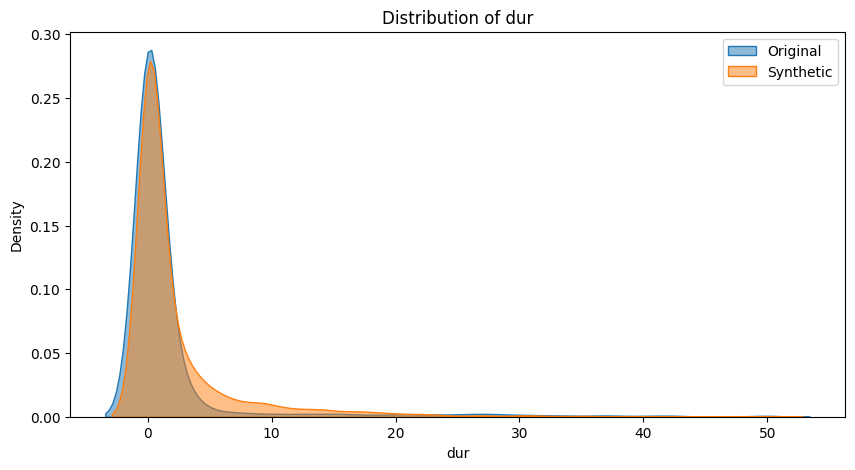

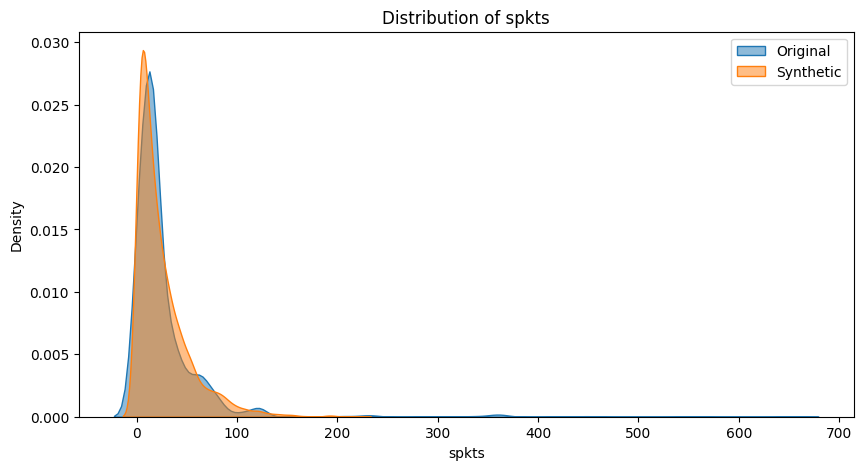

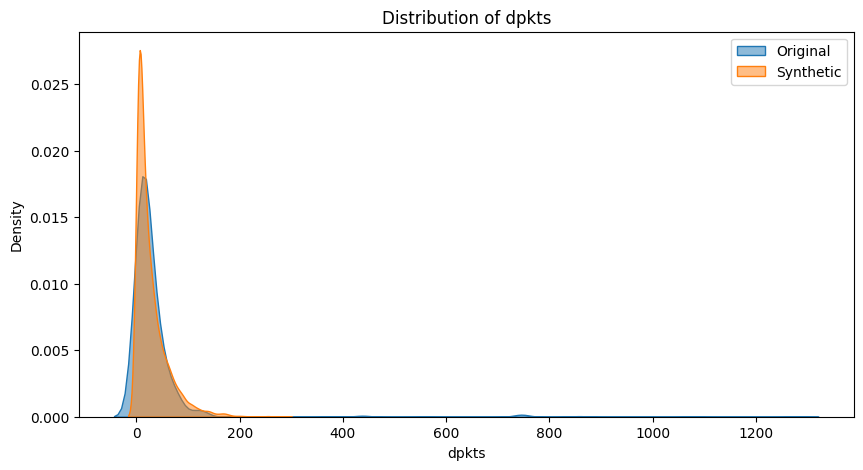

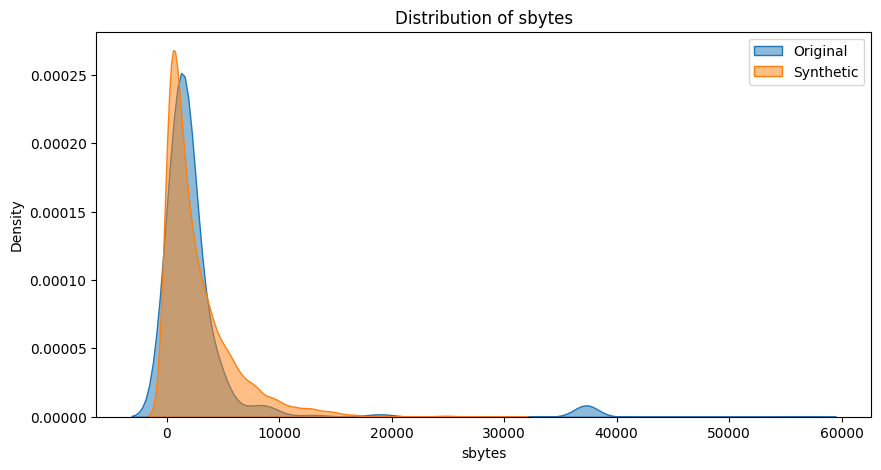

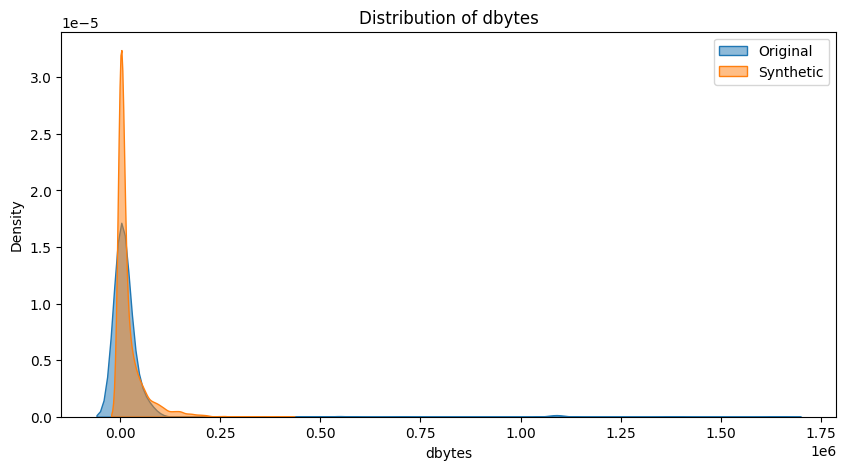

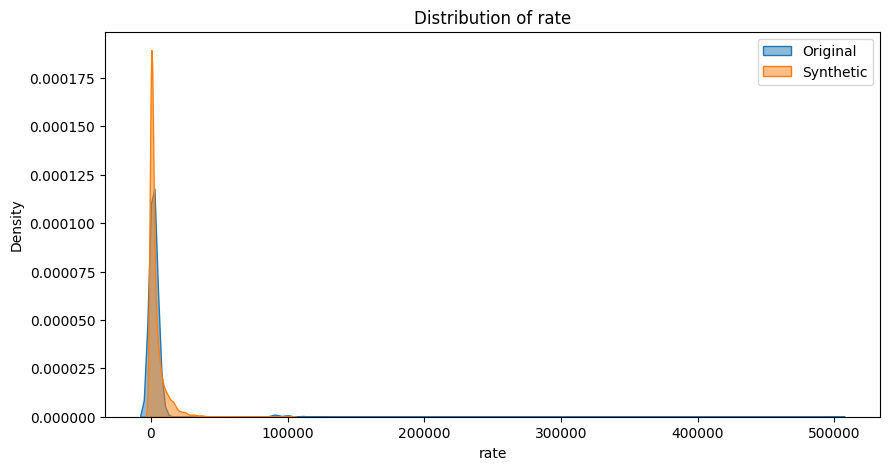

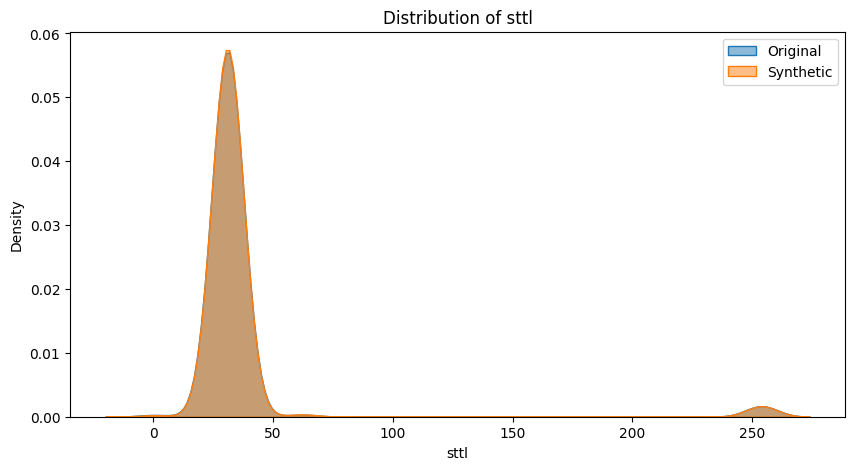

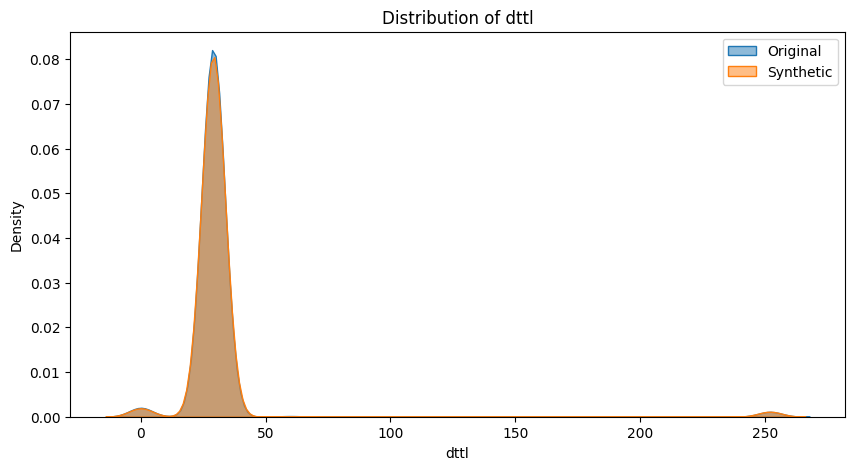

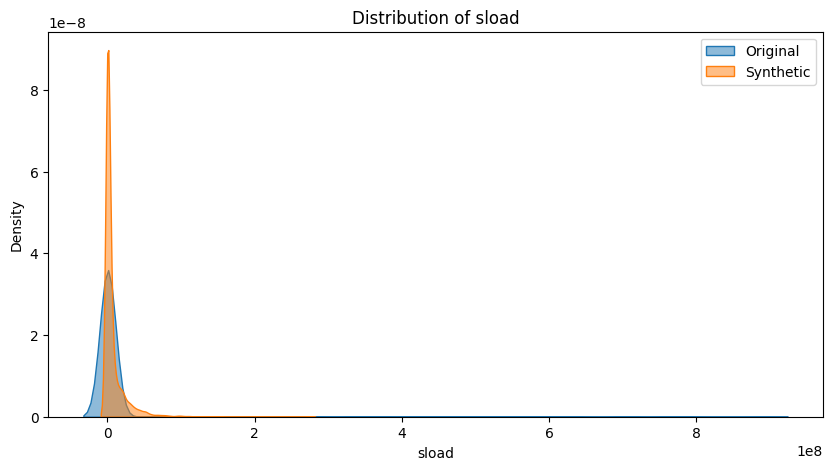

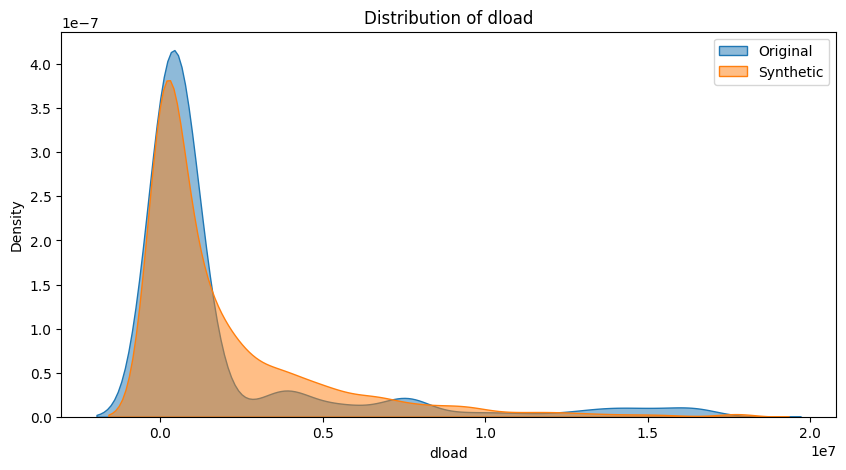

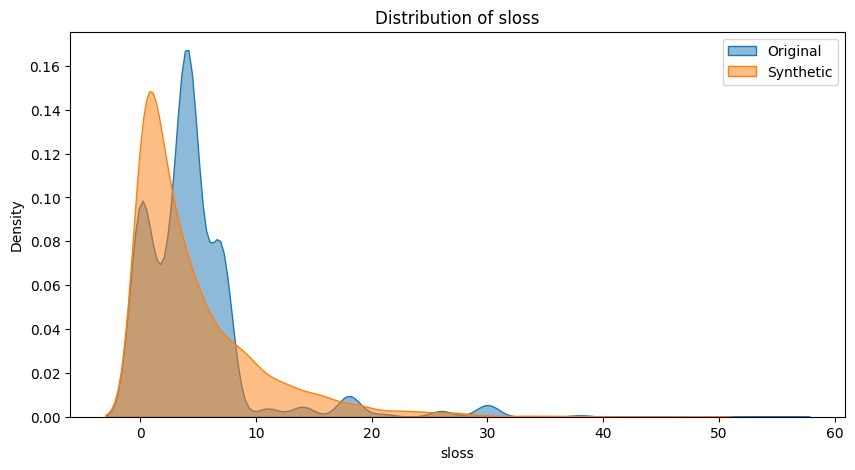

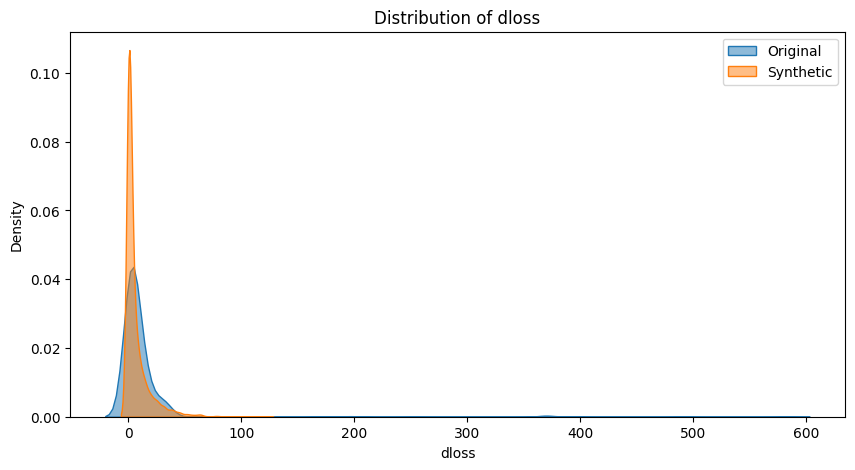

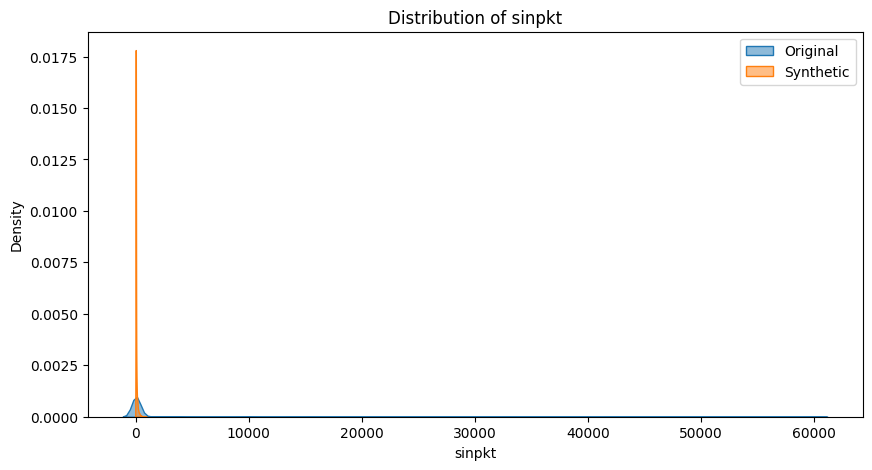

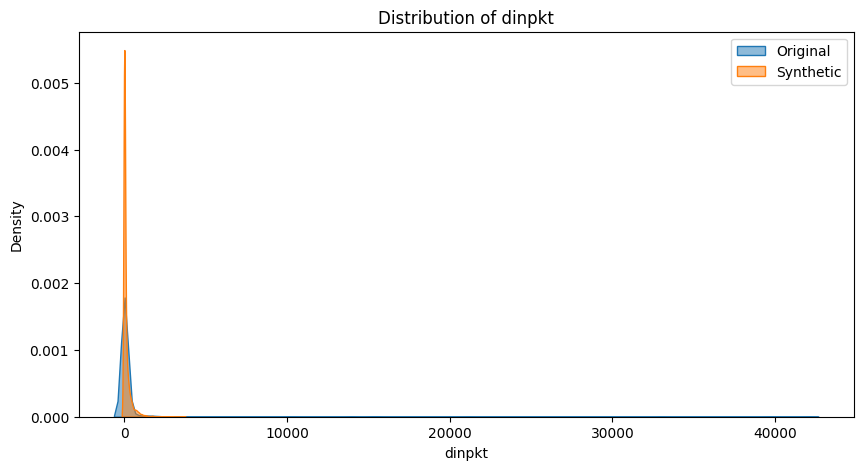

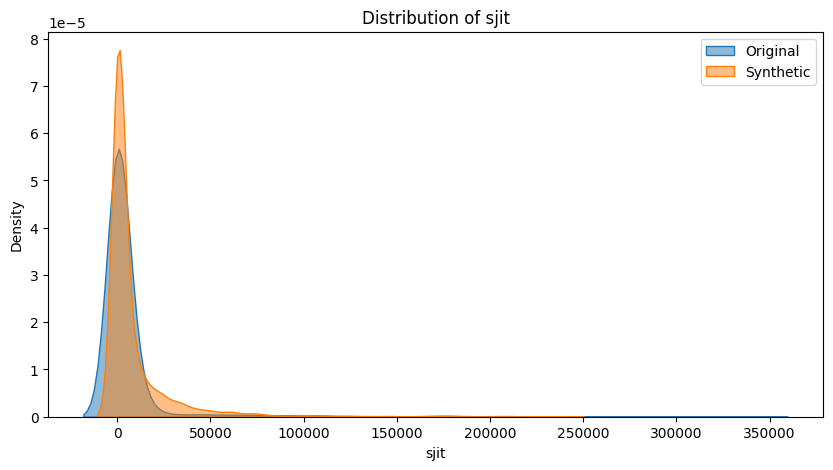

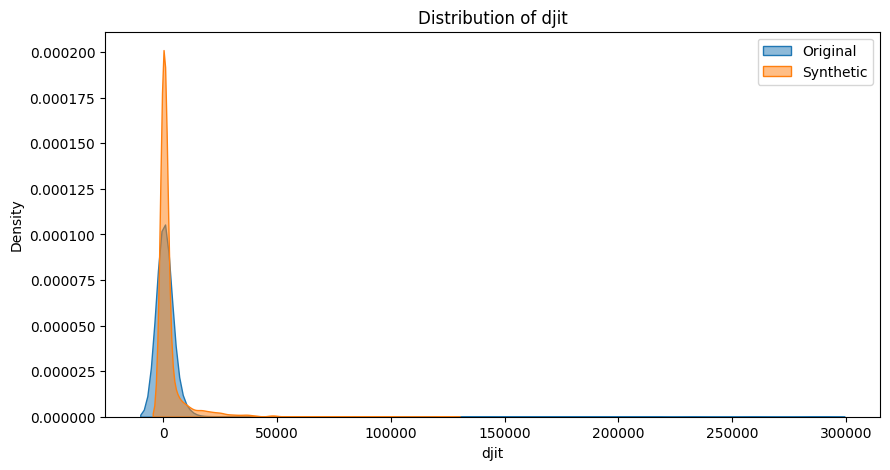

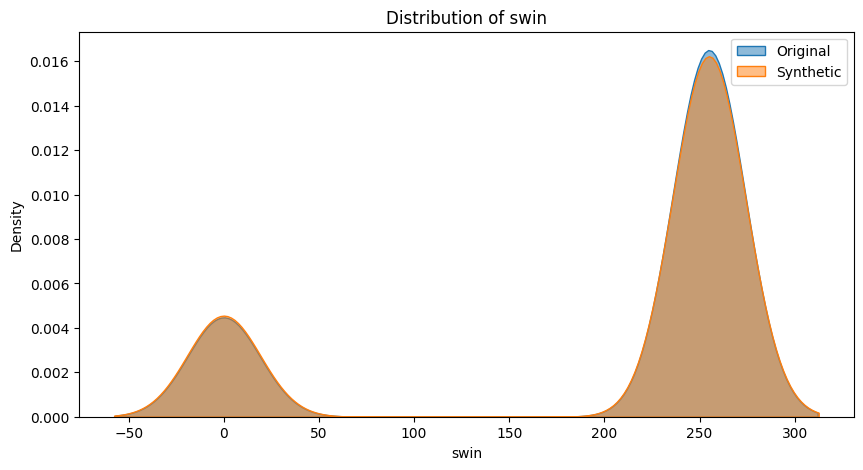

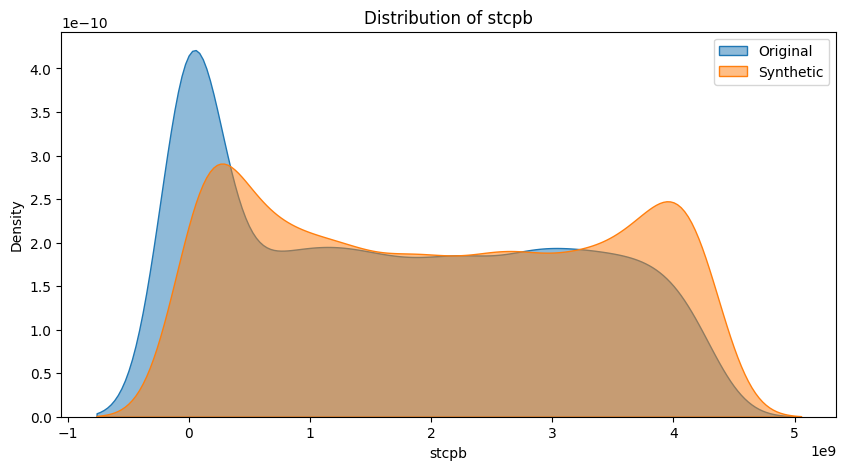

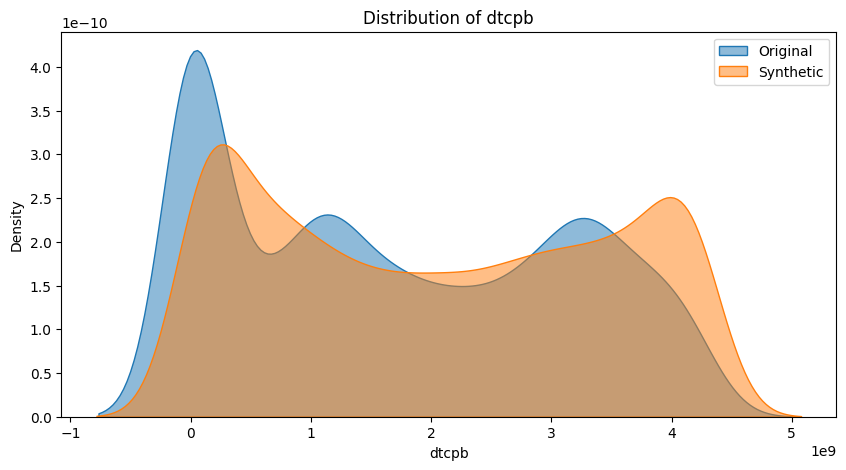

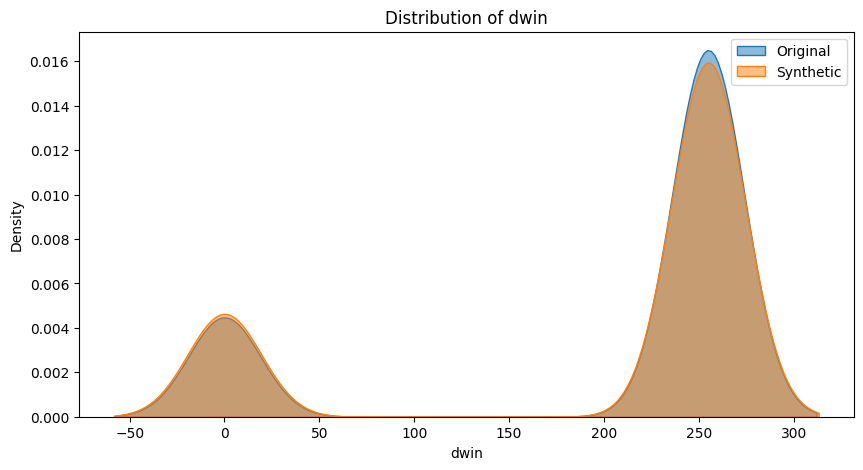

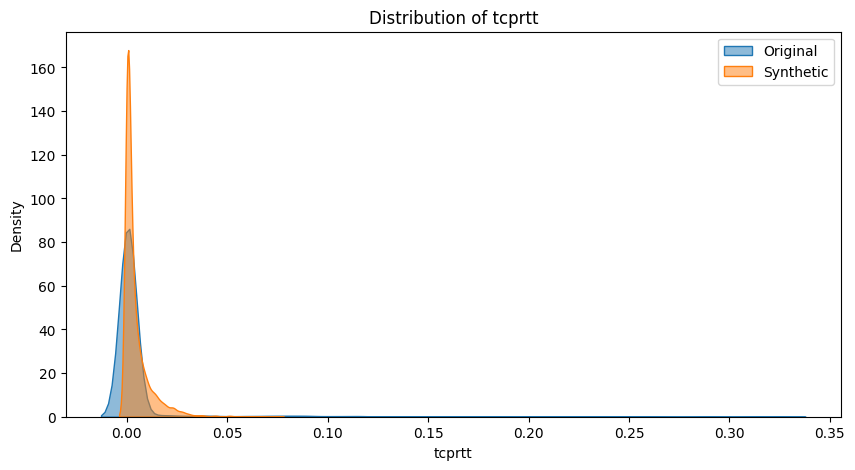

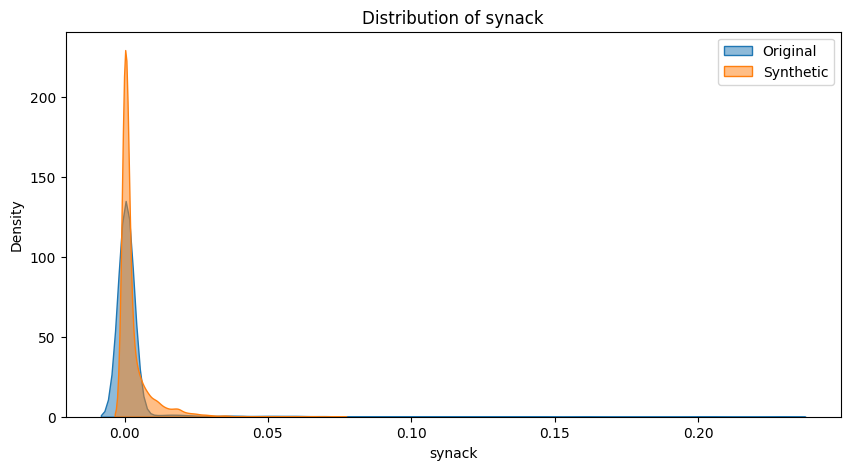

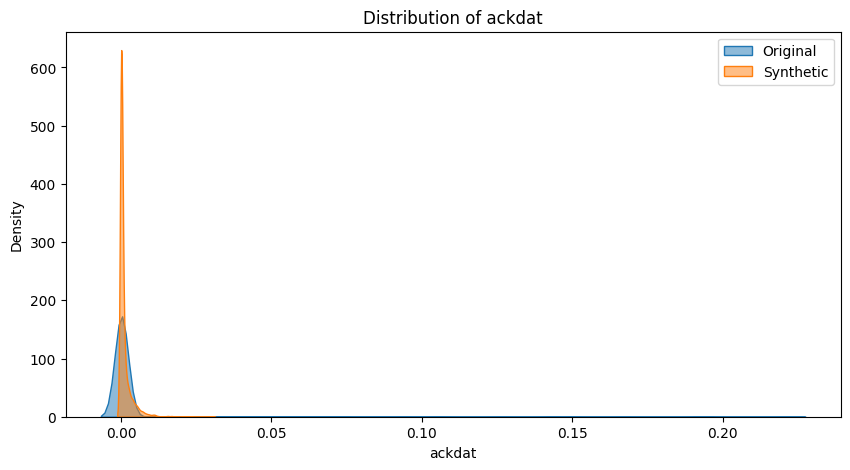

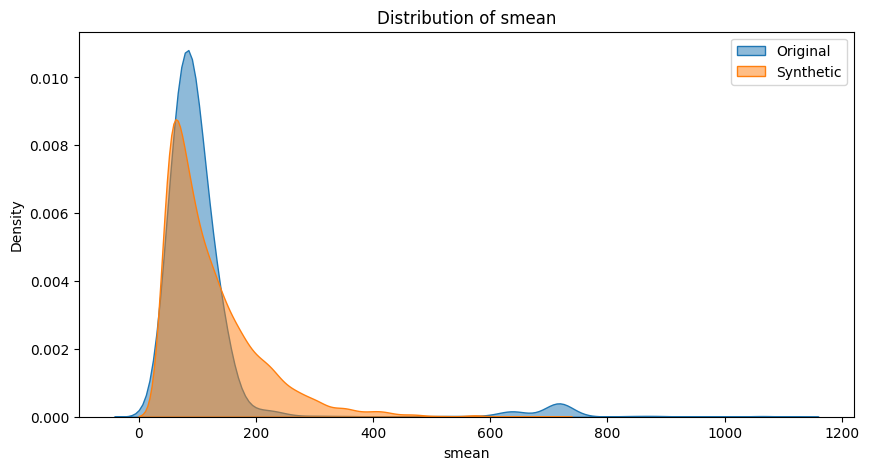

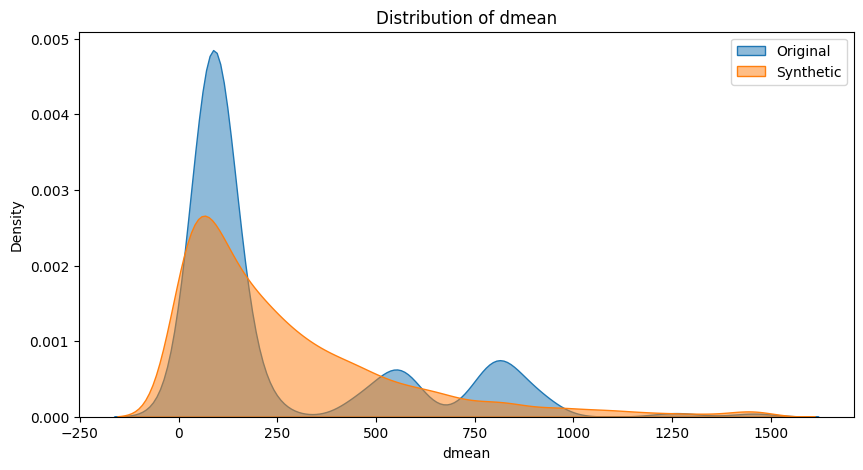

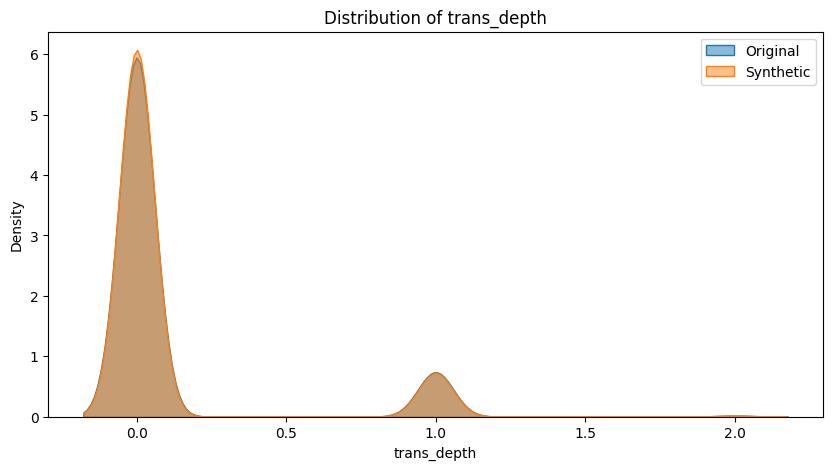

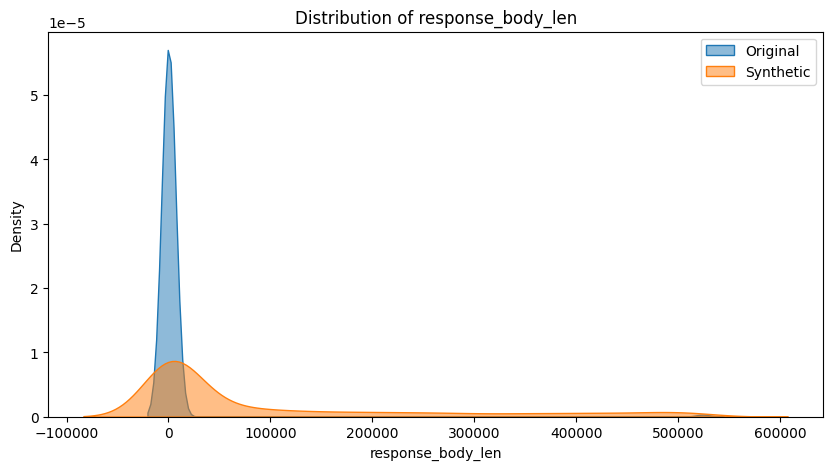

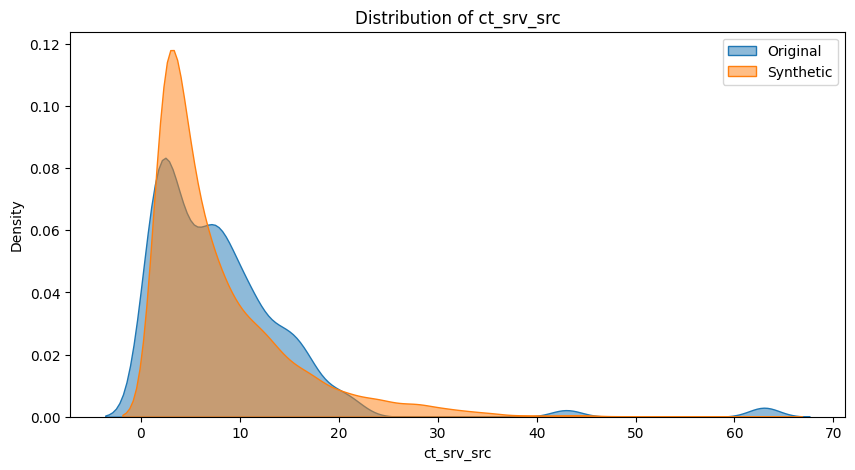

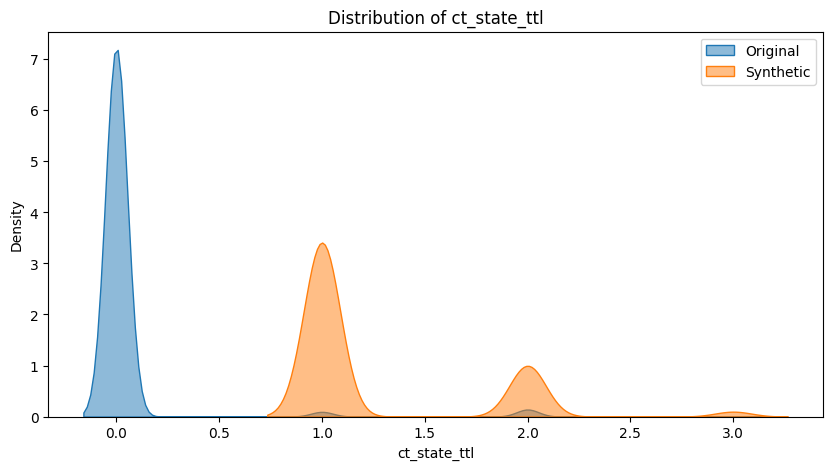

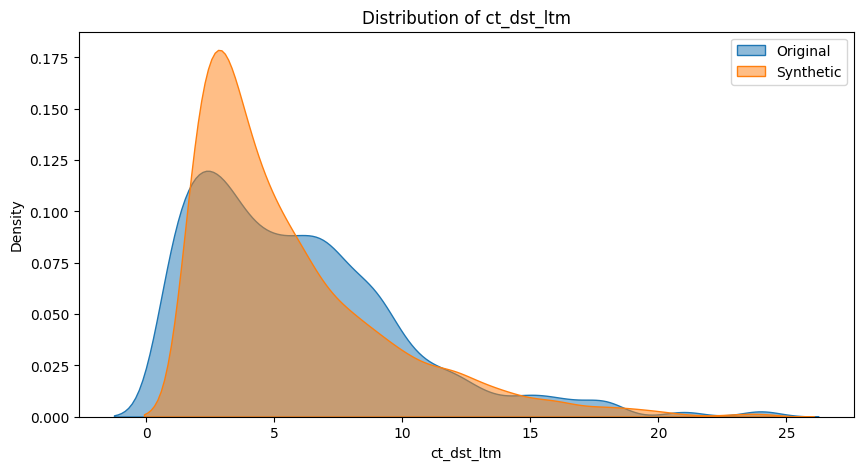

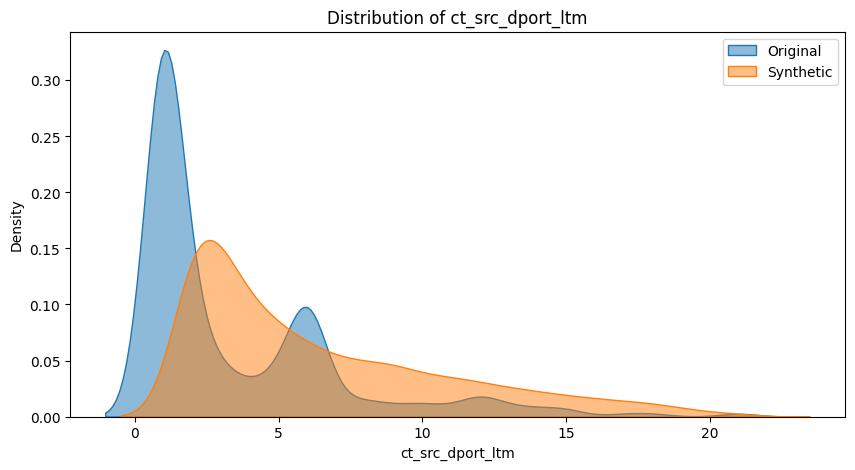

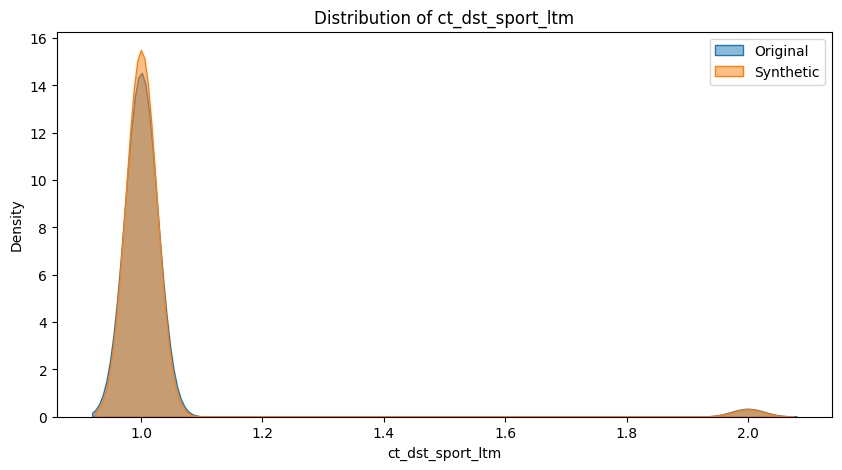

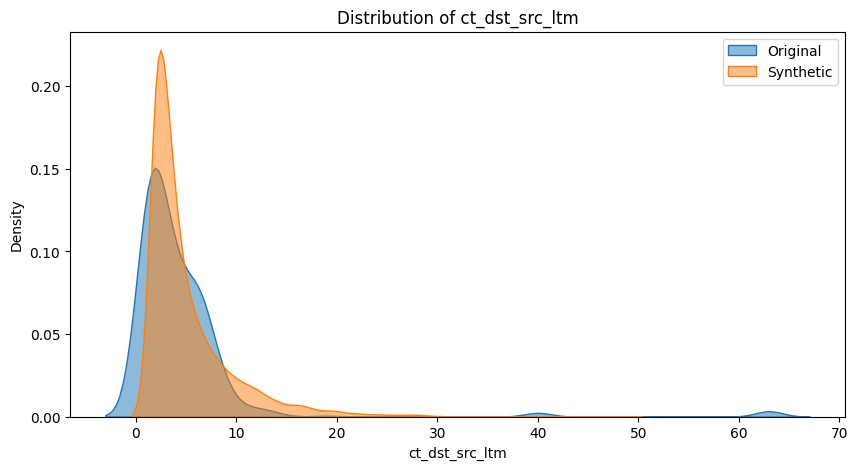

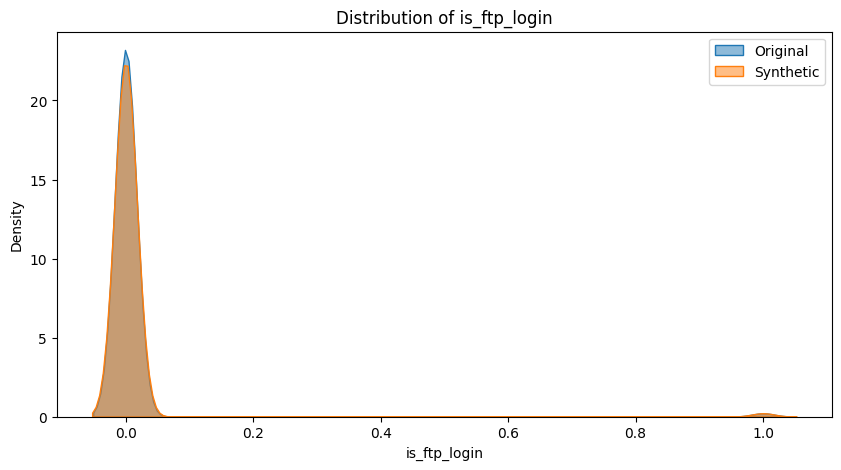

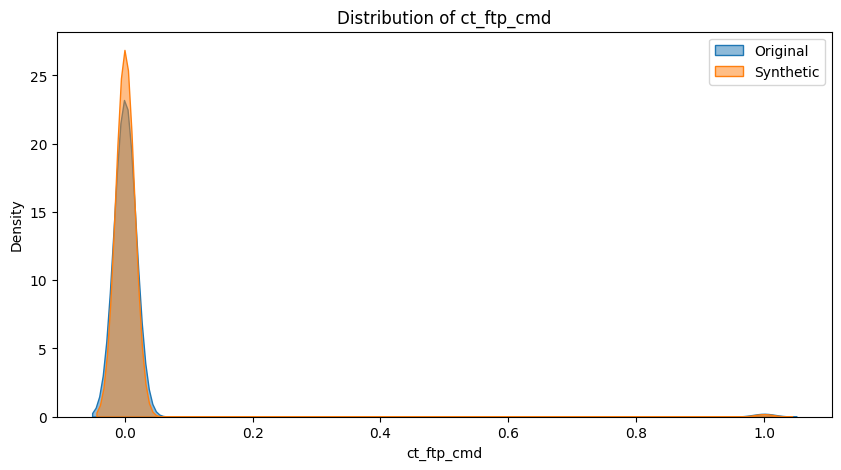

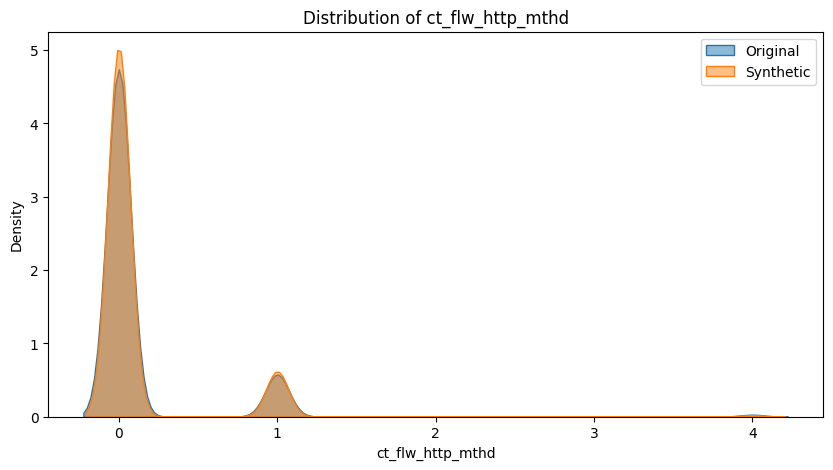

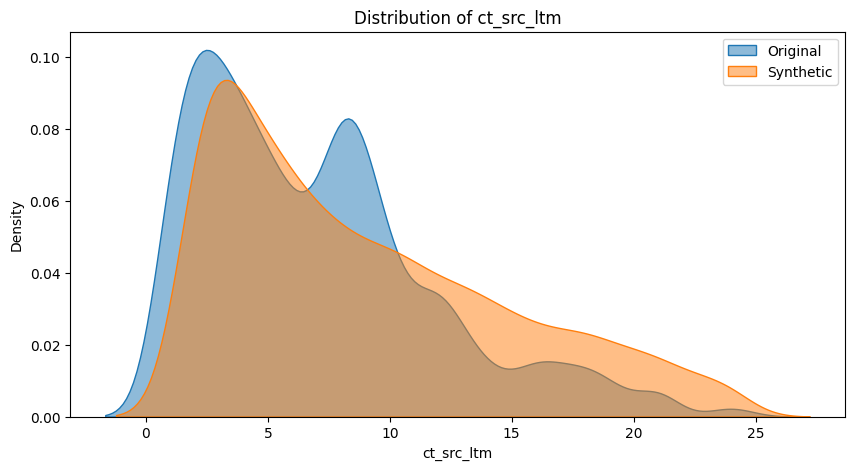

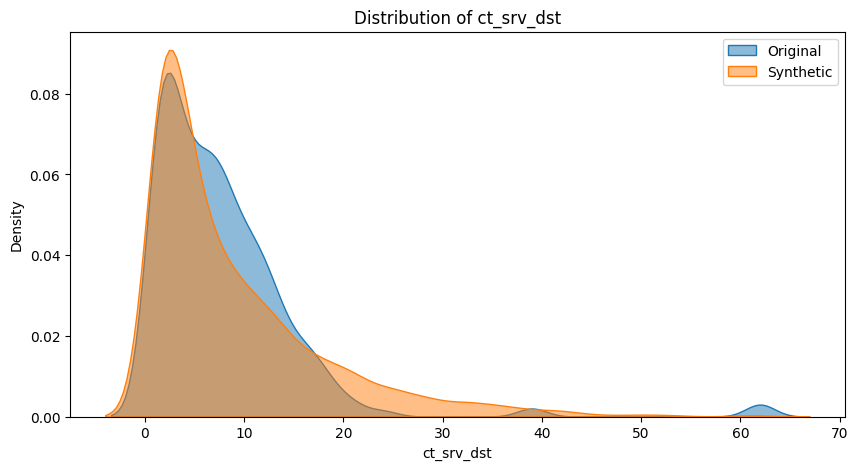

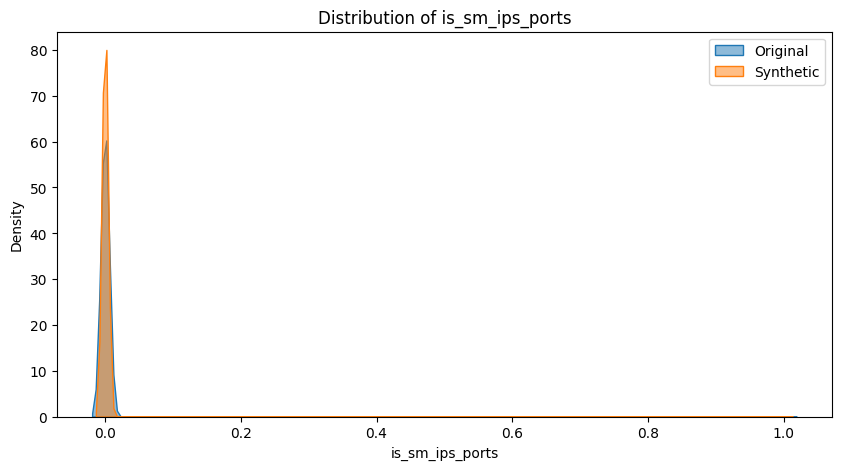

In [18]:
# Print data distributions of numerical columns and compare to original data
# usando kde en lugar de bins
numerical_cols = original_data.select_dtypes(include="number").columns
remove_cols = ["id", "label"]
numerical_cols = [col for col in numerical_cols if col not in remove_cols]
for col in numerical_cols:
    plt.figure(figsize=(10, 5))

    sns.kdeplot(original_data[col], label="Original", fill=True, common_norm=False, alpha=0.5)
    sns.kdeplot(synthetic_data[col], label="Synthetic", fill=True, common_norm=False, alpha=0.5)

    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Density")
    plt.legend()
    plt.show()

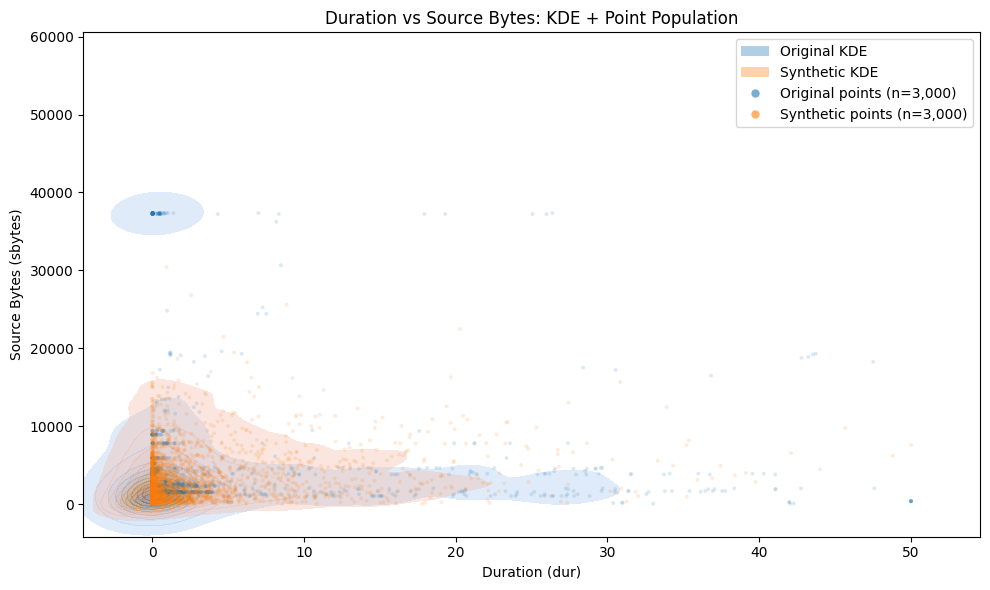

In [21]:
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

# Duration vs bytes: 2D KDE + sampled point population overlay
x_col = "dur"
y_col = "sbytes"

orig_plot = original_data[[x_col, y_col]].dropna()
syn_plot = synthetic_data[[x_col, y_col]].dropna()

# Keep scatter readable on large datasets while still showing population structure.
max_points = 3000
orig_points = orig_plot.sample(n=min(max_points, len(orig_plot)), random_state=42)
syn_points = syn_plot.sample(n=min(max_points, len(syn_plot)), random_state=42)

orig_color = "#1f77b4"
syn_color = "#ff7f0e"

plt.figure(figsize=(10, 6))

sns.kdeplot(
    data=orig_plot,
    x=x_col,
    y=y_col,
    fill=True,
    levels=10,
    thresh=0.05,
    alpha=0.35,
    color=orig_color,
)
sns.kdeplot(
    data=syn_plot,
    x=x_col,
    y=y_col,
    fill=True,
    levels=10,
    thresh=0.05,
    alpha=0.35,
    color=syn_color,
)

plt.scatter(
    orig_points[x_col],
    orig_points[y_col],
    s=8,
    alpha=0.15,
    color=orig_color,
    edgecolors="none",
)
plt.scatter(
    syn_points[x_col],
    syn_points[y_col],
    s=8,
    alpha=0.15,
    color=syn_color,
    edgecolors="none",
)

legend_handles = [
    Patch(facecolor=orig_color, alpha=0.35, label="Original KDE"),
    Patch(facecolor=syn_color, alpha=0.35, label="Synthetic KDE"),
    Line2D(
        [0],
        [0],
        marker="o",
        linestyle="",
        markerfacecolor=orig_color,
        markeredgecolor="none",
        markersize=6,
        alpha=0.6,
        label=f"Original points (n={len(orig_points):,})",
    ),
    Line2D(
        [0],
        [0],
        marker="o",
        linestyle="",
        markerfacecolor=syn_color,
        markeredgecolor="none",
        markersize=6,
        alpha=0.6,
        label=f"Synthetic points (n={len(syn_points):,})",
    ),
]

plt.title("Duration vs Source Bytes: KDE + Point Population")
plt.xlabel("Duration (dur)")
plt.ylabel("Source Bytes (sbytes)")
plt.legend(handles=legend_handles, loc="best", frameon=True)
plt.tight_layout()
plt.show()